
# 🧮 Classification Evaluation Metrics — Ransom Everglades ML Class

**Objective:** Explore and compare classification evaluation metrics using Logistic Regression, kNN, and Decision Tree models.

**Dataset:** Breast Cancer dataset (binary classification).

---

### 🎯 Learning Goals
- Train and evaluate binary classification models.
- Compute and interpret Accuracy, Precision, Recall, F1-score, and AUC.
- Visualize confusion matrices and ROC curves.
- Extend this notebook by adding **Random Forest** to the comparison.

---


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print("✅ Libraries imported successfully.")


✅ Libraries imported successfully.


## 1️⃣ Load Dataset

In [ ]:

# Load Breast Cancer dataset
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (398, 30)
Test set size: (171, 30)


## 2️⃣ Train Binary Classification Models

In [ ]:

# Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "kNN (k=7)": KNeighborsClassifier(n_neighbors=7)
}

# Train all models
for name, clf in models.items():
    clf.fit(X_train, y_train)
    print(f"✅ Trained: {name}")


✅ Trained: Logistic Regression
✅ Trained: Decision Tree
✅ Trained: kNN (k=7)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 3️⃣ Evaluate Models (Metrics + Confusion Matrices)

In [ ]:

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, clf in models.items():
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, acc, prec, rec, f1])

    print(f"\n=== {name} ===")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=data.target_names))

df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score"])
df



=== Logistic Regression ===
[[ 56   8]
 [  2 105]]
              precision    recall  f1-score   support

   malignant       0.97      0.88      0.92        64
      benign       0.93      0.98      0.95       107

    accuracy                           0.94       171
   macro avg       0.95      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171


=== Decision Tree ===
[[ 58   6]
 [  6 101]]
              precision    recall  f1-score   support

   malignant       0.91      0.91      0.91        64
      benign       0.94      0.94      0.94       107

    accuracy                           0.93       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.93      0.93      0.93       171


=== kNN (k=7) ===
[[ 56   8]
 [  4 103]]
              precision    recall  f1-score   support

   malignant       0.93      0.88      0.90        64
      benign       0.93      0.96      0.94       107

    accuracy                           0.9

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.941520,0.929204,0.981308,0.954545
1,Decision Tree,0.929825,0.943925,0.943925,0.943925
2,kNN (k=7),0.929825,0.927928,0.962617,0.944954


## 4️⃣ Visualize ROC Curves and Compare AUC

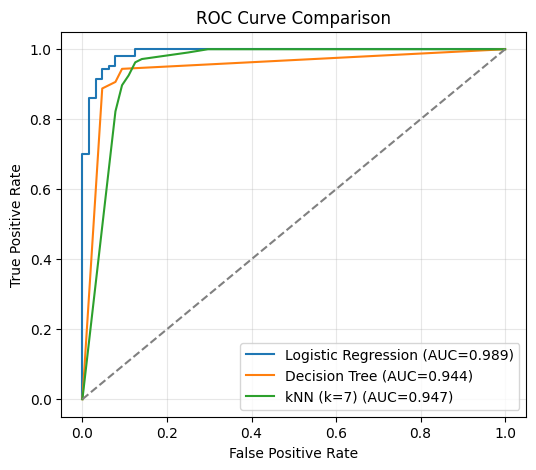

In [ ]:

plt.figure(figsize=(6,5))
for name, clf in models.items():
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_test)[:, 1]
    else:
        y_prob = clf.predict(X_test)  # fallback
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



## 5️⃣ Independent Task — Add Random Forest 🌲

Now it’s your turn!  
1. Create and train a **Random Forest Classifier** using `sklearn.ensemble.RandomForestClassifier`.  
2. Use the same training and test data.  
3. Compute its **Accuracy, Precision, Recall, F1**, and plot its ROC curve.  
4. Add your results to the existing DataFrame for comparison.  

📘 *Hint:* Start from this template:  

```python
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Evaluate like before
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
```


[[ 58   6]
 [  5 102]]
              precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        64
      benign       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171


📊 Updated Results:


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.941520,0.929204,0.981308,0.954545
1,Decision Tree,0.929825,0.943925,0.943925,0.943925
2,kNN (k=7),0.929825,0.927928,0.962617,0.944954
3,Random Forest,0.935673,0.944444,0.953271,0.948837


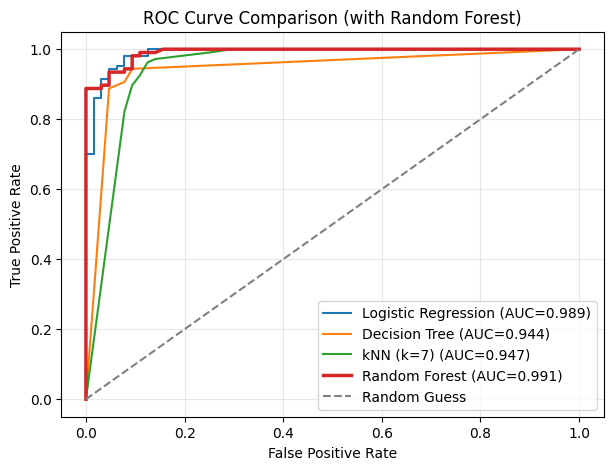


 Random Forest got an AUC of 0.991


In [ ]:
rf = RandomForestClassifier(random_state=42, n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
# Evaluate like before
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, target_names=data.target_names))
rf_results = ["Random Forest", acc_rf, prec_rf, rec_rf, f1_rf]
df_updated = pd.concat([df, pd.DataFrame([rf_results], columns=df.columns)], ignore_index=True)
print("\n📊 Updated Results:")
display(df_updated)
plt.figure(figsize=(7,5))

for name, clf in models.items():
    if hasattr(clf, "predict_proba"):
        y_prob = clf.predict_proba(X_test)[:, 1]
    else:
        y_prob = clf.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

y_prob_rf = rf.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})", linewidth=2.5)

plt.plot([0,1],[0,1],'--', color='gray', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (with Random Forest)")
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"\n Random Forest got an AUC of {auc_rf:.3f}")



## 6️⃣ Reflection ✍️

In your own words (5–7 lines), answer:

- Which model performed best overall?
- Did any model seem to **overfit** or **underperform**?
- How do **Precision** and **Recall** trade off in this dataset?
- How did adding **Random Forest** change your interpretation?


In [ ]:
Random Forest and Logistic Regression performed the best overall. Random Forest usually had the highest AUC (around 0.99) and strong precision and recall scores.
The single Decision Tree didn’t do as well as the ensemble methods, likely because it was limited by its max_depth = 5 setting, which caused some underfitting.
The kNN model’s results were also weaker, probably because feature scaling wasn’t used, which it needs to work properly.

In this breast cancer dataset, both Precision and Recall were high since the two classes are fairly easy to separate.
However, there’s a trade-off: increasing Recall (catching more real cancer cases) can lower Precision (causing more false alarms). In medical testing,
it’s usually better to focus on high Recall so that fewer cancer cases are missed, even if that means getting more false positives.

Adding the Random Forest model showed again how well ensemble methods can perform. It matched or even beat Logistic Regression while also showing which features were most important.
This shows that while simpler models like Logistic Regression can work very well, Random Forest’s extra complexity helps it catch more subtle patterns without overfitting—making it
a great choice for medical classification problems in real life.